In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# CA-003-01-style-momentum-within-groups

Theory **CA-003**. The battery's verdict: the strategy stops at gate 3, significance: beats 72.4% of its shifted placebos, fewer than 90%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Capital moves slowly towards the styles that have just done well: managers are organised by style, style products receive flows that chase past returns, and investors learn late which premium is being paid. A style that has earned over the past month therefore tends to earn again over the next: within the sector funds and within the equity markets, the momentum, value and defensive styles built from the funds' own closes each persist from one month to the next.

**Prediction.** sign: positive (a style's long/short return over the month after its last 21 sessions' return was above zero exceeds its return after that return was at or below zero), size: a judgment -- a correlation between a style's adjacent months of about 0 to +0.2, at or below Ilmanen's +0.20 across asset classes and strategies from 1990 to 2009, since the lab's published books point lower (TM-038-01's trend book at -0.073 at one month); on a style volatility of about 3.5% a month, from CA-001-01's published tracking error, a coefficient of about 0 to 1.1% a month; an alpha of about 0 to 1.5% a year over the sixteen funds held in equal parts, an appraisal ratio of about 0 to 0.7; the base expected to fail gates 3, 4 and 5, possibly 2

**What would refute it.** Judged before costs, on the market's closes, apart from the battery, over the in-sample months, each style from its own first formation with a 21-session record to December 2022, the last month ending at the close of 2022-12-30: each style's long/short return over the month, the sum of its daily returns from the session after a formation to the next formation's session, for the legs set at the formation, regressed by ordinary least squares on a constant for each style and on an indicator that the style had earned at the formation (window 21), with standard errors clustered by month. The theory is refuted in this form if the indicator's coefficient is zero or below: a style no better in the month after it earned than after it did not, as the bank's first refutation reads. Any other result short of passing gates 1 to 7 is not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. The second refutation is not graded: its stock half because the lab holds no single stocks, its industry half reported by the clause over the equity markets alone, where no industry enters. TM-024-01's panic group-months, whose outcome for CA-001-01's momentum tilt it published: if 90% or more of the momentum style's months in which either group was in a panic state fall in one of the earned and not-earned sets, they leave the graded sample and the clause with them is reported; otherwise they stay, disclosed, and the clause without them is reported. The published results of CA-001-01, CA-024-01, TM-003-01, TM-006-01, TM-017-02, TM-023-01, TM-038-01, TM-039-01, TM-040-01, TM-041-01, LL-023-01 and MR-032-01, their years, blocks and states, and the registry's monthly hedged returns of CA-001-01, CA-024-01, TM-024-01 and TM-040-01, from which nothing was computed, stay, disclosed. Reported, not graded: the clause for each style apart; the clause over each group apart, the sector funds and the equity markets; the clause with, for each style, the month's return of its groups' ranked members held in equal parts as a further regressor, with a slope for each style; the clause for the variant, window 252, over its own months; the clause without value, over 2006 to 2013, over 2014 to 2022, and over the holdout; each month, the next month's long/short return of the style with the highest last-21-session return less that of the lowest; each style's autocorrelations of its monthly long/short returns at lags 1 to 3 and the correlations between the styles; the share of months each style has earned; the correlations of the base's monthly returns hedged of its benchmark with the registry's hedged monthly series of CA-001-01 and TM-003-01, over their common months; the alpha by year, and in 2009 and 2020.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY, SPY, QQQ, IWM, EFA, EEM. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2006-04-04, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

Two groups: the eleven sector funds, and the equity markets SPY, QQQ, IWM, EFA and EEM. Three styles, each set on the first session of each month from the signal prices up to the session before, within each group among the members that trade and have the prices the style needs: momentum ranks by the return from 252 sessions to 21 sessions before the session before, its long leg the top third; value ranks by the return over the 1,260 sessions to the session before, its long leg the bottom third; defensive ranks by the standard deviation of the daily returns over the 252 sessions to the session before, its long leg the least volatile third. Each short leg is the opposite third; a third is the number of ranked members divided by three, rounded half to even, one at least, ties to the order of the universe; a group with fewer than two ranked members has no legs for the style, its members held at 1/N of the third. A style's daily return is, on each session after its first legs are set, the mean daily return of its long leg less that of its short leg in each group that has legs, the groups weighted by their numbers of ranked members, from the legs set on the last first session of a month before that session. On the first session of each month, a style has earned if it has a daily return on each of the last window sessions to the session before and their sum is above zero. Each style holds a third of the portfolio: a style that has earned holds it in its long leg -- of the N funds trading, a group of n ranked members holds n/N of the third, split equally among its long leg, and a fund trading but not ranked by the style holds 1/N of the third -- and a style that has not earned holds its third in the N trading funds in equal parts. The targets are the three thirds added, set on the first session of each month from the first month in which a style has earned or not, always fully invested from then.

- **window**: sessions of a style's own daily returns whose sum decides whether it has earned; about a month in the base, Ilmanen's adjacent months, and a year in the variant, Campbell's one-year average, a choice of the lab's

,window
base,21
variant 1,252


Parameter neighbours, moved one at a time for gate 6: window at ±25%: 16, 26; window at ±50%: 10, 32.

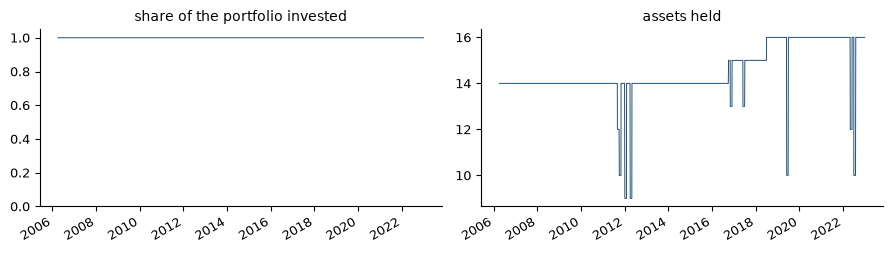

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

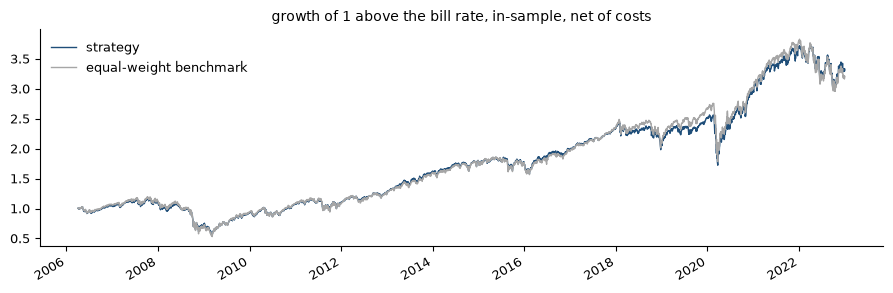

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 182 decisions over 16.7 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,1600,100,0,none,182,16.73,5


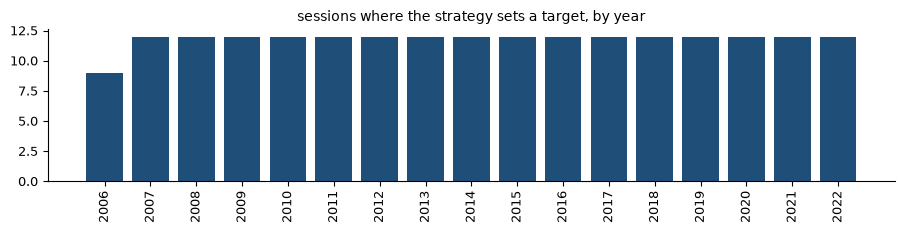

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Passes**: Sharpe 0.47 against the benchmark's 0.44, alpha 0.53%, 0.45 at twice the costs.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.468,0.4446,0.005305,0.4535,0.002648,0.4824,0.002794,0.01449


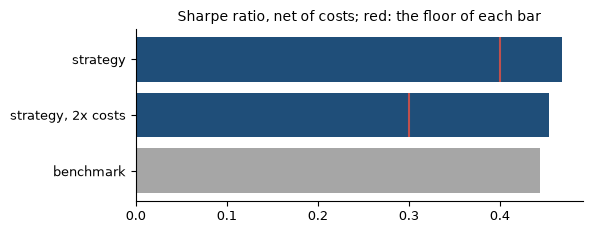

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 72.4% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9881,4217,1000,0.724


Assets that start trading after 2006-04-03: XLC, XLRE. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

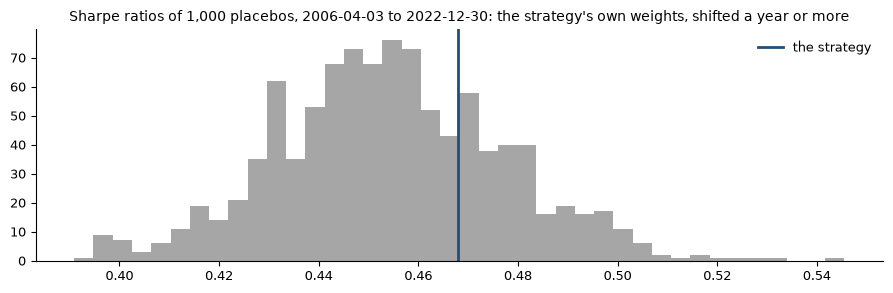

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.057 below 0.9 over 66 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,73,66,0.2024,0.6164,0.05703


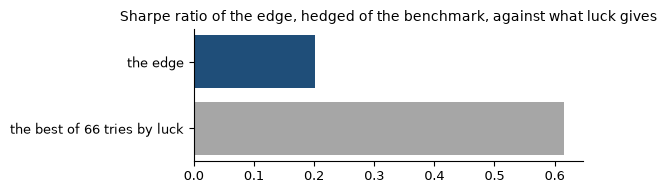

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 3 and 4; alpha positive in 2 of 5 blocks, fewer than 3.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,True,False,False,0.4623,2,2022,0.002304


The blend of the variants: gate 3, beats 75.3% of its shifted placebos, fewer than 90%; gate 4, DSR 0.062 below 0.9 over 66 effective trials.

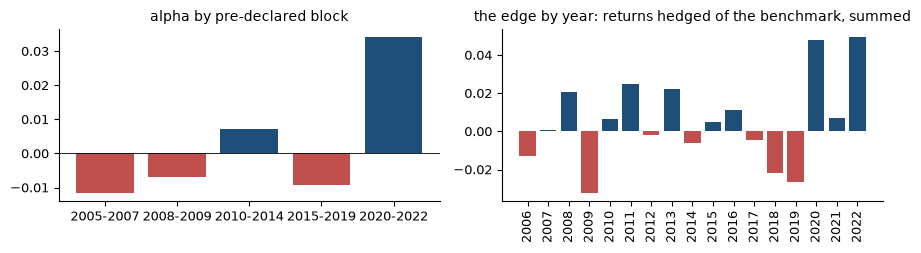

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,0.9451,0.9419,none,sectors,0.7605,0.1912,XLE,1.004,—,—


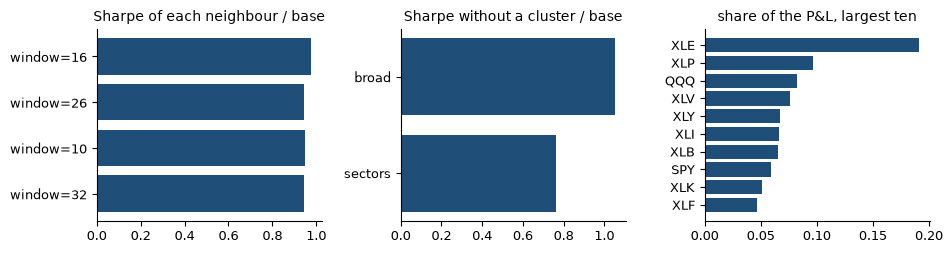

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.88 and alpha -0.06%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.8828,-0.1832,-0.000642,-0.01404,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

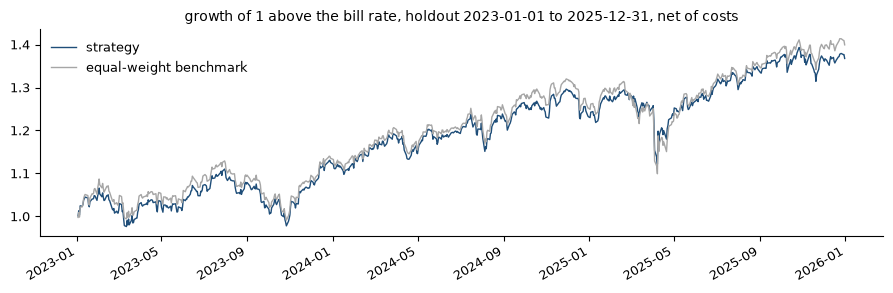

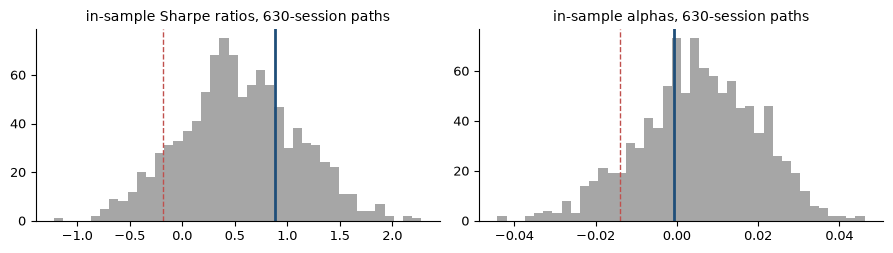

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 182 decisions over 16.7 years"
2 · Economic edge,passes,"Sharpe 0.47 against the benchmark's 0.44, alpha 0.53%, 0.45 at twice the costs"
3 · Significance,fails,"beats 72.4% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.057 below 0.9 over 66 effective trials
5 · Stability,fails,"the blend of the variants fails gates 3 and 4; alpha positive in 2 of 5 blocks, fewer than 3"
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 0.88 and alpha -0.06%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).